In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
import tiktoken 
from tqdm.auto import tqdm 
 
sns.set_theme(style='whitegrid', context='notebook') 
DATASET_DIR = Path('open_ragbench/pdf/arxiv') 
CORPUS_DIR = DATASET_DIR / 'corpus' 
assert CORPUS_DIR.exists(), f'Corpus not found: {CORPUS_DIR.resolve()}' 
encoding = tiktoken.get_encoding('cl100k_base') 
corpus_files = sorted(CORPUS_DIR.glob('*.json')) 
len(corpus_files)

c:\Users\gurma\Downloads\openrag\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1000

In [2]:
# One row per original dataset section. Tables/images are dictionaries keyed by asset ID. 
section_rows, paper_rows = [], [] 
 
for file_path in tqdm(corpus_files, desc='Profiling papers', unit='paper'): 
    with file_path.open(encoding='utf-8') as f: 
        paper = json.load(f) 
    sections = paper.get('sections', []) 
    paper_rows.append({'paper_id': paper['id'], 'title': paper.get('title', ''), 
                       'categories': ', '.join(paper.get('categories', [])), 'n_sections': len(sections)}) 
    for section in sections: 
        text = section.get('text') or '' 
        tables, images = section.get('tables') or {}, section.get('images') or {} 
        section_rows.append({ 
            'paper_id': paper['id'], 'section_id': section.get('section_id'), 
            'text_chars': len(text), 
            'text_tokens': len(encoding.encode(text, disallowed_special=())), 
            'n_tables': len(tables), 'n_images': len(images), 
            'has_table': bool(tables), 'has_image': bool(images), 
        }) 
 
papers_df = pd.DataFrame(paper_rows) 
sections_df = pd.DataFrame(section_rows) 
sections_df.head()

Profiling papers:   0%|          | 0/1000 [00:00<?, ?paper/s]

Profiling papers: 100%|██████████| 1000/1000 [01:33<00:00, 10.66paper/s]


,paper_id,section_id,text_chars,text_tokens,n_tables,n_images,has_table,has_image
0,2401.01872v2,0,20426,3931,0,2,False,True
1,2401.01872v2,1,2008,683,0,0,False,False
2,2401.01872v2,2,9767,2579,0,0,False,False
3,2401.01872v2,3,7217,1918,0,0,False,False
4,2401.01872v2,4,33490,8192,1,0,True,False


In [3]:
summary = pd.Series({ 
    'papers (JSON files)': len(papers_df), 
    'total sections': len(sections_df), 
    'total text tokens': int(sections_df['text_tokens'].sum()), 
    'mean tokens / section': round(sections_df['text_tokens'].mean(), 1), 
    'median tokens / section': int(sections_df['text_tokens'].median()), 
    'p95 tokens / section': int(sections_df['text_tokens'].quantile(0.95)), 
    'total tables': int(sections_df['n_tables'].sum()), 
    'total images': int(sections_df['n_images'].sum()), 
    'sections with tables': int(sections_df['has_table'].sum()), 
    'sections with images': int(sections_df['has_image'].sum()), 
}) 
summary.to_frame('value')

,value
papers (JSON files),1000.0
total sections,18840.0
total text tokens,25426123.0
mean tokens / section,1349.6
median tokens / section,645.0
p95 tokens / section,4709.0
total tables,3486.0
total images,7752.0
sections with tables,1982.0
sections with images,3864.0


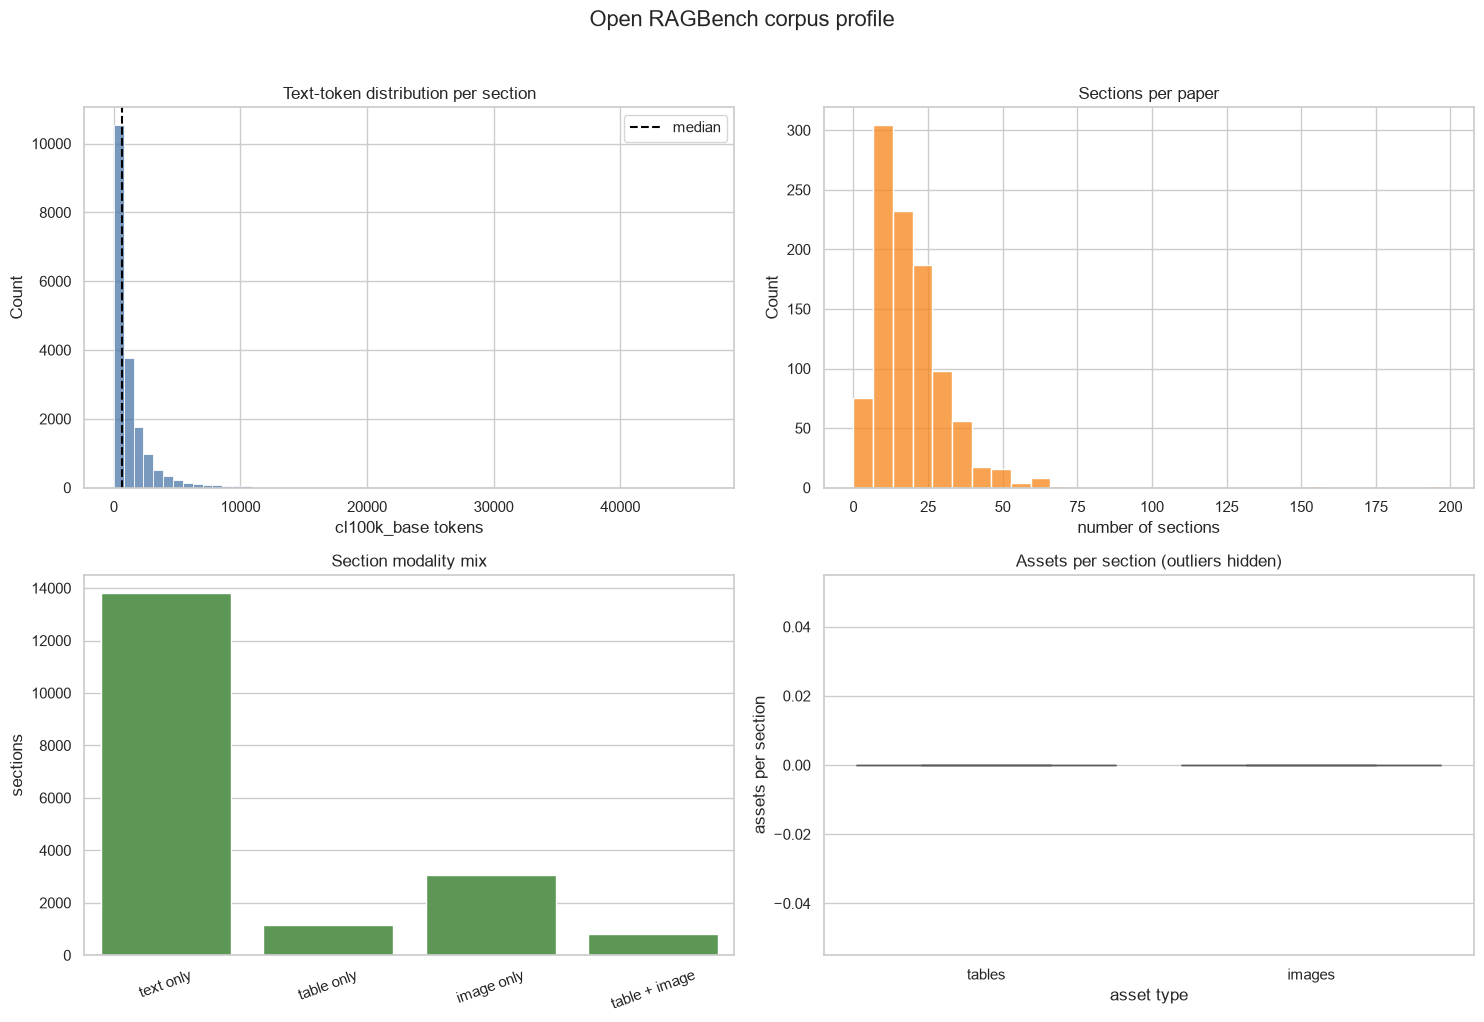

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 
 
# Long sections indicate where parent sections will need child chunks. 
sns.histplot(sections_df['text_tokens'], bins=60, ax=axes[0, 0], color='#4C78A8') 
axes[0, 0].axvline(sections_df['text_tokens'].median(), color='black', ls='--', label='median') 
axes[0, 0].set(title='Text-token distribution per section', xlabel='cl100k_base tokens') 
axes[0, 0].legend() 
 
sns.histplot(papers_df['n_sections'], bins=30, ax=axes[0, 1], color='#F58518') 
axes[0, 1].set(title='Sections per paper', xlabel='number of sections') 
 
modality_counts = pd.Series({ 
    'text only': (~sections_df['has_table'] & ~sections_df['has_image']).sum(), 
    'table only': (sections_df['has_table'] & ~sections_df['has_image']).sum(), 
    'image only': (~sections_df['has_table'] & sections_df['has_image']).sum(), 
    'table + image': (sections_df['has_table'] & sections_df['has_image']).sum(), 
}) 
sns.barplot(x=modality_counts.index, y=modality_counts.values, ax=axes[1, 0], color='#54A24B') 
axes[1, 0].set(title='Section modality mix', xlabel='', ylabel='sections') 
axes[1, 0].tick_params(axis='x', rotation=20) 
 
assets = pd.DataFrame({'tables': sections_df['n_tables'], 'images': sections_df['n_images']}).melt(var_name='asset type', value_name='assets per section') 
sns.boxplot(data=assets, x='asset type', y='assets per section', ax=axes[1, 1], color='#B279A2', showfliers=False) 
axes[1, 1].set(title='Assets per section (outliers hidden)') 
 
fig.suptitle('Open RAGBench corpus profile', fontsize=16, y=1.02) 
plt.tight_layout() 
plt.show()

In [5]:
# Estimate how often an original section fits directly in a chunking budget. 
limits = [512, 768, 1024, 1536, 2048,4096] 
chunking_readiness = pd.DataFrame({ 
    'max tokens': limits, 
    'sections fitting directly': [int((sections_df['text_tokens'] <= limit).sum()) for limit in limits], 
}) 
chunking_readiness['percent fitting'] = (100 * chunking_readiness['sections fitting directly'] / len(sections_df)).round(1) 
chunking_readiness

,max tokens,sections fitting directly,percent fitting
0,512,8213,43.6
1,768,10408,55.2
2,1024,12068,64.1
3,1536,14215,75.5
4,2048,15528,82.4
5,4096,17640,93.6


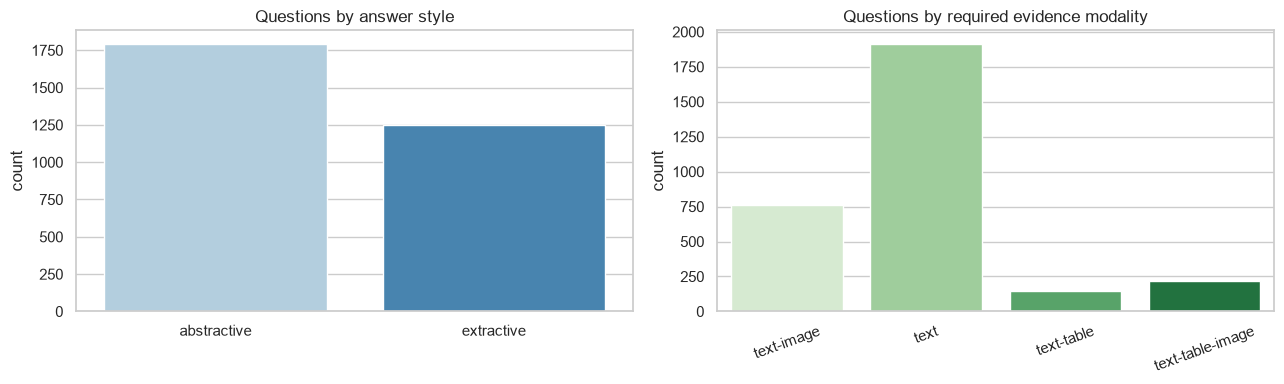

queries
type        source                   
abstractive text                  893
            text-image            630
            text-table            105
            text-table-image      165
extractive  text                 1021
            text-image            133
            text-table             43
            text-table-image       55

In [6]:
with (DATASET_DIR / 'queries.json').open(encoding='utf-8') as f: 
    queries = json.load(f) 
queries_df = pd.DataFrame.from_dict(queries, orient='index').rename_axis('query_id').reset_index() 
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4)) 
sns.countplot(data=queries_df, x='type', ax=axes[0], hue='type', legend=False, palette='Blues') 
axes[0].set(title='Questions by answer style', xlabel='') 
sns.countplot(data=queries_df, x='source', ax=axes[1], hue='source', legend=False, palette='Greens') 
axes[1].set(title='Questions by required evidence modality', xlabel='') 
axes[1].tick_params(axis='x', rotation=20) 
plt.tight_layout() 
plt.show() 
queries_df.groupby(['type', 'source']).size().rename('queries').to_frame()

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Match the text chunking configuration used by scripts/chunk_and_ingest.py.
splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1024,
    chunk_overlap=100,
    separators=['\n\n', '\n', '. ', ' ', ''],
)

chunk_rows = []
for file_path in tqdm(corpus_files, desc='Simulating chunks', unit='paper'):
    paper = json.loads(file_path.read_text(encoding='utf-8'))
    for section in paper.get('sections', []):
        chunks = splitter.split_text(section.get('text') or '')
        for chunk in chunks:
            chunk_rows.append({
                'paper_id': paper['id'],
                'section_id': section['section_id'],
                'tokens': len(encoding.encode(chunk, disallowed_special=())),
                'characters': len(chunk),
            })

chunks_df = pd.DataFrame(chunk_rows)
chunk_summary = pd.Series({
    'total chunks': len(chunks_df),
    'mean tokens per chunk': round(chunks_df['tokens'].mean(), 1),
    'mean characters per chunk': round(chunks_df['characters'].mean(), 1),
    'mean chunks per section': round(chunks_df.groupby(['paper_id', 'section_id']).size().mean(), 2),
    'mean chunks per document': round(chunks_df.groupby('paper_id').size().mean(), 2),
})
chunk_summary.to_frame('value')

Simulating chunks: 100%|██████████| 1000/1000 [01:01<00:00, 16.18paper/s]


,value
total chunks,39358.00
mean tokens per chunk,662.10
mean characters per chunk,2180.10
mean chunks per section,2.09
mean chunks per document,39.48


In [ ]:
##TODO:show split by how many what